# The Invisible Patients: 11,456 Rare Diseases and the Data That Maps Them

There are roughly 7,000 to 10,000 rare diseases documented worldwide. Individually, each one affects a tiny fraction of humanity. Collectively? They affect around 300 million people on Earth. That is more than the entire population of the United States.

Here is the cruel paradox of rare diseases: each one is too uncommon to attract serious funding, too complex to diagnose quickly, and too scattered across medical coding systems to study easily. A child born with Multiple Epiphyseal Dysplasia Macrocephaly Facial Dysmorphism Syndrome (yes, that is a real name) might wait years for a diagnosis because the doctor has literally never heard of it.

This notebook dives into the **Orphanet Rare Disease Database**, a dataset of 11,456 rare disorders mapped across seven international medical classification systems. We are going to explore how these diseases distribute across onset ages, inheritance patterns, and disorder categories, find the gaps in our medical knowledge (spoiler: they are enormous), and ultimately build a model that predicts the inheritance pattern of a disease from its other attributes.

The journey goes like this: first we meet the data and understand its shape, then we dig into the patterns hiding in 11,000+ disorders, run proper statistical tests on what we find, engineer features that capture the real signal, and finally build a classifier that can predict how a rare disease passes through families. Let's begin.

---

**Find My Work**

**Kaggle:** [kaggle.com/seki32](https://www.kaggle.com/seki32) | Daily notebooks, EDA, ML/DL experiments

**GitHub:** [github.com/Rekhii](https://github.com/Rekhii) | All code and repositories

## 1. Data Loading and First Look

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

COLORS = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
          '#44BBA4', '#E94F37', '#393E41', '#D4A373', '#6D6875']

print("Libraries loaded. Let's meet our data.")

Libraries loaded. Let's meet our data.


In [2]:
df = pd.read_csv('/kaggle/input/datasets/ahsanneural/rare-diseases-orphadata-2026/rare_diseases_complete.csv')

print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nThat is {df.shape[0]:,} rare diseases, each mapped across {df.shape[1]} attributes.")
print("Let's see what we are working with.")

Dataset shape: 11,456 rows x 15 columns
Memory usage: 6.62 MB

That is 11,456 rare diseases, each mapped across 15 attributes.
Let's see what we are working with.


In [3]:
df.head(10)

,OrphaCode,Name,DisorderType,DisorderGroup,ICD-11,MONDO,ICD-10,OMIM,UMLS,MeSH,MedDRA,GARD,DiseaseName,AgeOfOnset,TypeOfInheritance
0,166024,Multiple epiphyseal dysplasia-macrocephaly-fac...,Disease,Disorder,LD24.61,11778.0,Q77.3,607131.0,C4304500,NaN,NaN,NaN,Multiple epiphyseal dysplasia-macrocephaly-fac...,"Infancy, Neonatal",Autosomal recessive
1,166032,Multiple epiphyseal dysplasia-miniepiphyses sy...,Disease,Disorder,LD24.61,12254.0,Q77.3,609325.0,C5924992,C563735,NaN,NaN,Multiple epiphyseal dysplasia-miniepiphyses sy...,"Childhood, Infancy",NaN
2,58,Alexander disease,Disease,Disorder,8A44.2,8752.0,G93.8,203450.0,C0270726,D038261,10083059.0,5774.0,Alexander disease,All ages,Autosomal dominant
3,166029,Multiple epiphyseal dysplasia-severe proximal ...,Disease,Disorder,LD24.61,12253.0,Q77.3,609324.0,C5924993,C563736,NaN,NaN,Multiple epiphyseal dysplasia-severe proximal ...,Childhood,NaN
4,61,Alpha-mannosidosis,Disease,Disorder,5C56.21,9561.0,E77.1,248500.0,C0024748,D008363,10083855.0,6968.0,Alpha-mannosidosis,"Childhood, Infancy, Neonatal",Autosomal recessive
5,166038,"Metaphyseal chondrodysplasia, Kaitila type",Disease,Disorder,LD24.7,9594.0,Q78.5,250230.0,C1855217,C565400,NaN,NaN,"Metaphyseal chondrodysplasia, Kaitila type",Neonatal,NaN
6,166035,Brachydactyly-short stature-retinitis pigmento...,Malformation syndrome,Disorder,NaN,9598.0,Q87.8,250410.0,C5190709,NaN,NaN,NaN,Brachydactyly-short stature-retinitis pigmento...,"Childhood, Infancy",Autosomal recessive
7,93,Aspartylglucosaminuria,Disease,Disorder,5C56.21,8830.0,E77.1,208400.0,C0268225,D054880,10068220.0,5854.0,Aspartylglucosaminuria,Childhood,Autosomal recessive
8,585,Multiple sulfatase deficiency,Disease,Disorder,5C56.0Y,10088.0,E75.2,272200.0,C0268263,D052517,NaN,5061.0,Multiple sulfatase deficiency,"Adolescent, Antenatal, Childhood, Infancy, Neo...",Autosomal recessive
9,118,Beta-mannosidosis,Disease,Disorder,5C56.21,9562.0,E77.1,248510.0,C4048196,D044905,NaN,869.0,Beta-mannosidosis,"Adolescent, Adult, Childhood, Infancy, Neonatal",Autosomal recessive


In [4]:
df.dtypes

OrphaCode              int64
Name                  object
DisorderType          object
DisorderGroup         object
ICD-11                object
MONDO                float64
ICD-10                object
OMIM                 float64
UMLS                  object
MeSH                  object
MedDRA               float64
GARD                 float64
DiseaseName           object
AgeOfOnset            object
TypeOfInheritance     object
dtype: object

In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
OrphaCode,11456.0,NaN,NaN,NaN,212643.364787,205123.850994,5.0,57631.75,139460.5,317440.75,718255.0
Name,11456,11456,Conjunctival malignant melanoma,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DisorderType,11456,11,Disease,4713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DisorderGroup,11456,3,Disorder,7441,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ICD-11,6143,2279,LD2F.1Y,164,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MONDO,7988.0,NaN,NaN,NaN,51331.501627,243303.938481,44.0,10556.5,15792.5,18777.25,8000012.0
ICD-10,7541,1743,Q87.8,560,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OMIM,4978.0,NaN,NaN,NaN,429008.972479,201254.683854,100100.0,231018.75,601619.0,614377.25,621394.0
UMLS,9634,9630,C1837657,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MeSH,3216,3216,C562950,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### First Impressions

Right off the bat, a few things jump out:

1. **Every disease has a unique OrphaCode** (11,456 unique values for 11,456 rows). This is the primary key from Orphanet, the European rare disease database.

2. **The columns split into two groups**: identifier/mapping columns (OrphaCode, MONDO, ICD-10, ICD-11, OMIM, UMLS, MeSH, MedDRA, GARD) and descriptive columns (DisorderType, DisorderGroup, AgeOfOnset, TypeOfInheritance).

3. **The mapping columns are sparse**. Many diseases do not have codes in every classification system. This alone tells a story: our medical knowledge infrastructure has gaps, and rare diseases fall through them.

4. **AgeOfOnset and TypeOfInheritance are multi-valued strings** with commas separating multiple categories. A disease can onset in both infancy AND childhood, and it can be BOTH autosomal dominant AND recessive.

The identifier columns are not features in the traditional ML sense. They are references to other databases. The real analytical meat is in DisorderType, DisorderGroup, AgeOfOnset, TypeOfInheritance, and the *pattern of missingness* across those mapping columns. Let's dig in.

## 2. Exploratory Data Analysis

### 2.1 Missing Values Analysis

Before we look at what the data says, let's look at what it does NOT say. In a rare disease database, missing values are not just annoyances. They represent diseases that have not been mapped, classified, or fully understood. Every blank cell is a gap in human medical knowledge.

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct,
    'Present %': (100 - missing_pct).round(1)
}).sort_values('Missing %', ascending=False)

missing_df = missing_df[missing_df['Missing Count'] > 0]
print("Missing Values Summary")
print("=" * 50)
print(missing_df.to_string())
print(f"\nColumns with zero missing: OrphaCode, Name, DisorderType, DisorderGroup")

Missing Values Summary
                   Missing Count  Missing %  Present %
MedDRA                      9651       84.2       15.8
MeSH                        8240       71.9       28.1
GARD                        7623       66.5       33.5
OMIM                        6478       56.5       43.5
ICD-11                      5313       46.4       53.6
TypeOfInheritance           5218       45.5       54.5
AgeOfOnset                  4675       40.8       59.2
DiseaseName                 4082       35.6       64.4
ICD-10                      3915       34.2       65.8
MONDO                       3468       30.3       69.7
UMLS                        1822       15.9       84.1

Columns with zero missing: OrphaCode, Name, DisorderType, DisorderGroup


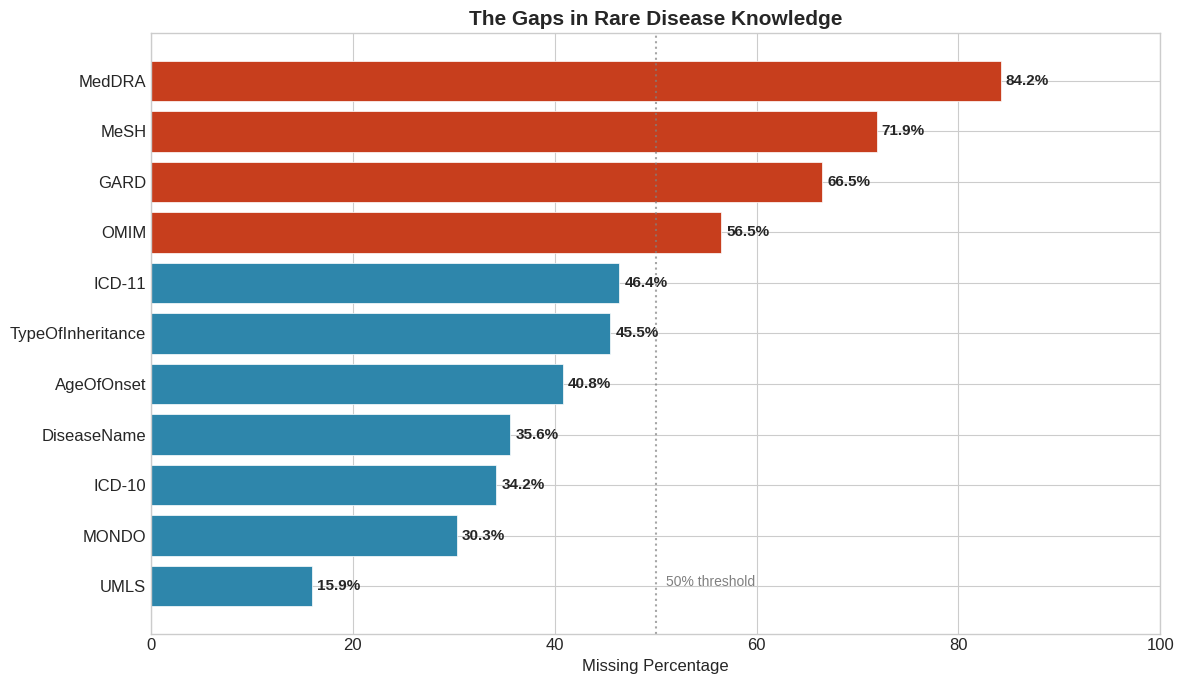

In [7]:
fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(
    missing_df.index[::-1],
    missing_df['Missing %'][::-1],
    color=[COLORS[0] if v < 50 else COLORS[3] for v in missing_df['Missing %'][::-1]],
    edgecolor='white',
    linewidth=0.5
)

for bar, val in zip(bars, missing_df['Missing %'][::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Missing Percentage')
ax.set_title('The Gaps in Rare Disease Knowledge', fontweight='bold', fontsize=15)
ax.set_xlim(0, 100)
ax.axvline(x=50, color='gray', linestyle=':', alpha=0.7)
ax.text(51, 0, '50% threshold', color='gray', fontsize=10)
plt.tight_layout()
plt.show()

**What this tells us:** The missingness is NOT random. It is systematic and it tells a story.

**MedDRA** (Medical Dictionary for Regulatory Activities) is missing for **84.2%** of diseases. This makes sense since MedDRA is primarily used for drug safety reporting, and most rare diseases do not have approved treatments yet. No drug, no MedDRA code.

**GARD** (Genetic and Rare Diseases Info Center) is missing for 66.5%. **MeSH** (Medical Subject Headings) is missing for 71.9%. These are US-centric databases, while Orphanet is European. The transatlantic gap in rare disease classification is real.

**AgeOfOnset** (40.8%) and **TypeOfInheritance** (45.5%) are missing for nearly half the diseases. For 5,000+ conditions, we literally do not know when they start or how they are inherited. That is not a data quality issue. That is a reflection of how much we still don't understand.

The four columns that are NEVER missing (OrphaCode, Name, DisorderType, DisorderGroup) are the ones assigned by Orphanet itself. The rest depend on external databases catching up.

### 2.2 Target Variable: TypeOfInheritance

For our modeling task, we will predict the inheritance pattern of a disease. This is clinically valuable because knowing how a disease is inherited helps genetic counselors advise families, helps researchers narrow down candidate genes, and helps clinicians understand recurrence risk.

But first, we need to understand what our target looks like.

In [8]:
inheritance = df['TypeOfInheritance'].dropna()
print(f"Diseases with known inheritance: {len(inheritance):,} out of {len(df):,} ({len(inheritance)/len(df)*100:.1f}%)")
print(f"Unique inheritance patterns (raw): {inheritance.nunique()}")

print("\nTop 15 inheritance patterns:")
print("=" * 60)
top_inh = inheritance.value_counts().head(15)
for pattern, count in top_inh.items():
    pct = count / len(inheritance) * 100
    print(f"  {pattern:<55} {count:>5} ({pct:.1f}%)")

Diseases with known inheritance: 6,238 out of 11,456 (54.5%)
Unique inheritance patterns (raw): 67

Top 15 inheritance patterns:
  Autosomal recessive                                      2141 (34.3%)
  Autosomal dominant                                       1355 (21.7%)
  Not applicable                                           1179 (18.9%)
  X-linked recessive                                        257 (4.1%)
  Unknown                                                   257 (4.1%)
  Autosomal dominant, Autosomal recessive                   251 (4.0%)
  Autosomal dominant, Not applicable                        151 (2.4%)
  Multigenic/multifactorial, Not applicable                  88 (1.4%)
  Not applicable, Unknown                                    86 (1.4%)
  Multigenic/multifactorial                                  82 (1.3%)
  X-linked dominant                                          57 (0.9%)
  Autosomal dominant, Autosomal recessive, X-linked recessive    46 (0.7%)
  Autosomal 

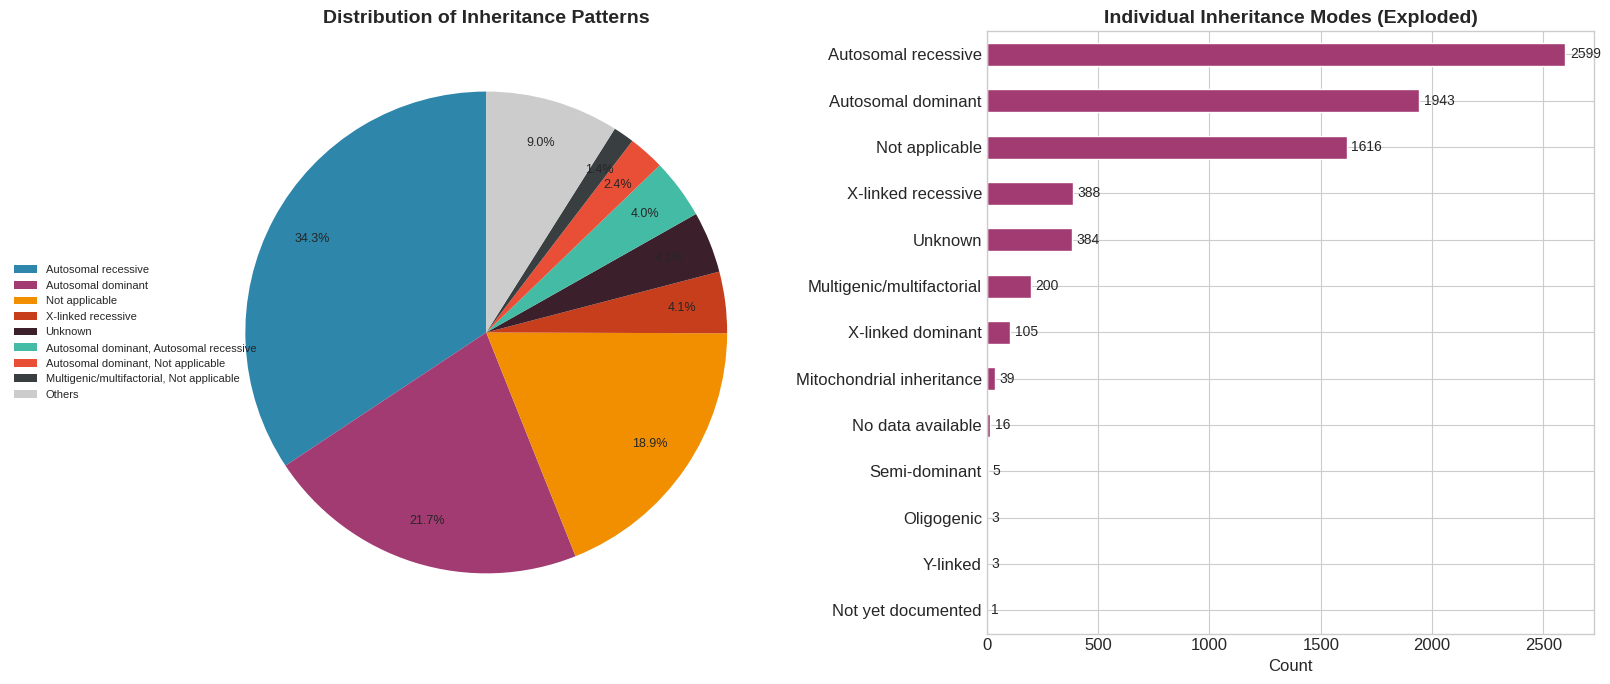

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top8 = inheritance.value_counts().head(8)
others = inheritance.value_counts().iloc[8:].sum()
plot_data = pd.concat([top8, pd.Series({'Others': others})])

colors_pie = COLORS[:8] + ['#cccccc']
wedges, texts, autotexts = axes[0].pie(
    plot_data.values, labels=None, autopct='%1.1f%%',
    colors=colors_pie, startangle=90, pctdistance=0.82
)
for t in autotexts:
    t.set_fontsize(9)
axes[0].set_title('Distribution of Inheritance Patterns', fontweight='bold')
axes[0].legend(plot_data.index, loc='center left', bbox_to_anchor=(-0.3, 0.5), fontsize=8)

single_vals = []
for val in inheritance:
    parts = [p.strip() for p in val.split(',')]
    single_vals.extend(parts)

single_counts = pd.Series(Counter(single_vals)).sort_values(ascending=True)
single_counts.plot.barh(ax=axes[1], color=COLORS[1], edgecolor='white')
axes[1].set_title('Individual Inheritance Modes (Exploded)', fontweight='bold')
axes[1].set_xlabel('Count')
for i, (val, count) in enumerate(single_counts.items()):
    axes[1].text(count + 20, i, str(count), va='center', fontsize=10)

plt.tight_layout()
plt.show()

**What this tells us:** The inheritance landscape is dominated by two giants: **Autosomal Recessive** (34.3%) and **Autosomal Dominant** (21.7%). Together they account for over half of all known inheritance patterns. This makes biological sense since most Mendelian diseases follow these two classic patterns.

But here is what makes this tricky for modeling: there are **67 unique raw patterns** because many diseases have MULTIPLE inheritance modes listed (e.g., "Autosomal dominant, Autosomal recessive"). The right panel shows what happens when we explode those comma-separated values into individual modes.

"Not applicable" is the third largest category. These are typically chromosomal abnormalities, somatic mutations (like cancers), or conditions caused by environmental factors during development rather than inherited genetic changes.

For modeling, we will need to simplify this into clean categories. More on that in feature engineering.

### 2.3 Univariate Analysis of Categorical Features

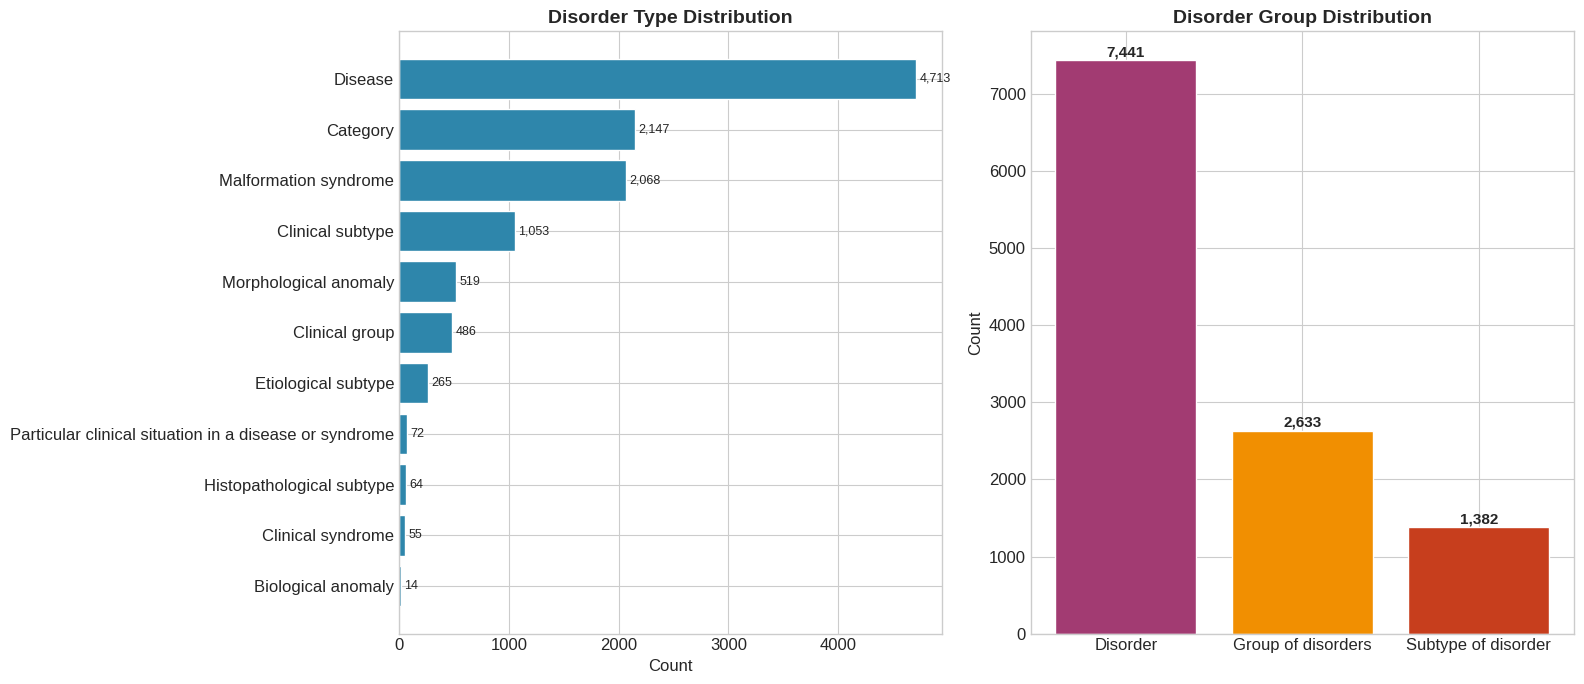

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

disorder_type = df['DisorderType'].value_counts()
bars1 = axes[0].barh(disorder_type.index[::-1], disorder_type.values[::-1], color=COLORS[0], edgecolor='white')
axes[0].set_title('Disorder Type Distribution', fontweight='bold')
axes[0].set_xlabel('Count')
for bar, val in zip(bars1, disorder_type.values[::-1]):
    axes[0].text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=9)

disorder_group = df['DisorderGroup'].value_counts()
bars2 = axes[1].bar(disorder_group.index, disorder_group.values, color=COLORS[1:4], edgecolor='white')
axes[1].set_title('Disorder Group Distribution', fontweight='bold')
axes[1].set_ylabel('Count')
for bar, val in zip(bars2, disorder_group.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{val:,}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

**DisorderType** has 11 categories but it is heavily skewed. **Disease** (4,713) dominates, followed by **Category** (2,147) and **Malformation syndrome** (2,068). The long tail includes niche types like "Biological anomaly" (14 entries) and "Clinical syndrome" (55 entries). The distinction matters: a "Disease" is a single clinical entity, a "Category" groups related conditions, and a "Malformation syndrome" involves multiple birth defects occurring together.

**DisorderGroup** is simpler with just three levels: **Disorder** (7,441), **Group of disorders** (2,633), and **Subtype of disorder** (1,382). This is a hierarchical classification. "Group of disorders" are umbrella categories, "Disorder" is the main level, and "Subtype" captures finer distinctions within a disorder.

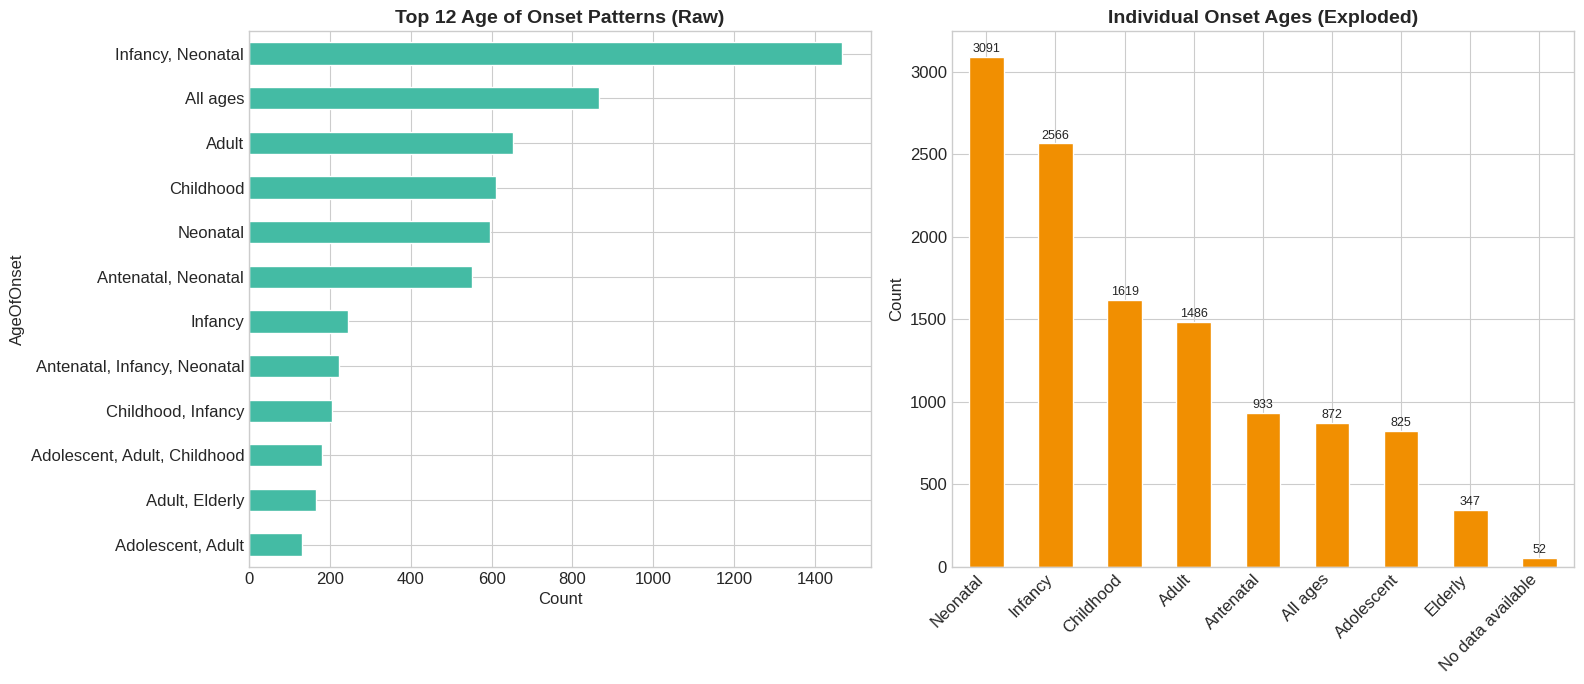

In [11]:
onset = df['AgeOfOnset'].dropna()

single_onsets = []
for val in onset:
    parts = [p.strip() for p in val.split(',')]
    single_onsets.extend(parts)

onset_counts = pd.Series(Counter(single_onsets)).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_raw = onset.value_counts().head(12)
top_raw.plot.barh(ax=axes[0], color=COLORS[5], edgecolor='white')
axes[0].set_title('Top 12 Age of Onset Patterns (Raw)', fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].invert_yaxis()

onset_counts.plot.bar(ax=axes[1], color=COLORS[2], edgecolor='white')
axes[1].set_title('Individual Onset Ages (Exploded)', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
for i, (idx, val) in enumerate(onset_counts.items()):
    axes[1].text(i, val + 30, str(val), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

**Age of Onset** reveals the brutal timing of rare diseases. The most common raw pattern is **"Infancy, Neonatal"** (1,466 diseases). When we explode the multi-valued entries, **Neonatal** dominates with 3,069 mentions, followed by **Infancy** at 2,454.

Let that sink in. The majority of rare diseases with known onset ages strike before a child reaches their second birthday. **Childhood** adds another 1,363, and **Antenatal** (before birth) contributes 1,002. Rare diseases are overwhelmingly diseases of the young.

The **"All ages"** category (867) represents conditions that can manifest at any point in life, which is a different kind of challenge for diagnosis since there is no typical window to watch for.

### 2.4 Bivariate Analysis: Features vs Inheritance

In [12]:
df_known = df[df['TypeOfInheritance'].notna()].copy()

def get_primary_inheritance(val):
    if pd.isna(val):
        return None
    parts = [p.strip() for p in val.split(',')]
    return parts[0]

df_known['PrimaryInheritance'] = df_known['TypeOfInheritance'].apply(get_primary_inheritance)

top_classes = df_known['PrimaryInheritance'].value_counts().head(6).index.tolist()
df_top = df_known[df_known['PrimaryInheritance'].isin(top_classes)].copy()

print(f"Working with top 6 inheritance classes covering {len(df_top):,} diseases:")
for cls in top_classes:
    count = (df_top['PrimaryInheritance'] == cls).sum()
    print(f"  {cls}: {count:,}")

Working with top 6 inheritance classes covering 6,129 diseases:
  Autosomal recessive: 2,221
  Autosomal dominant: 1,943
  Not applicable: 1,274
  Unknown: 257
  X-linked recessive: 257
  Multigenic/multifactorial: 177


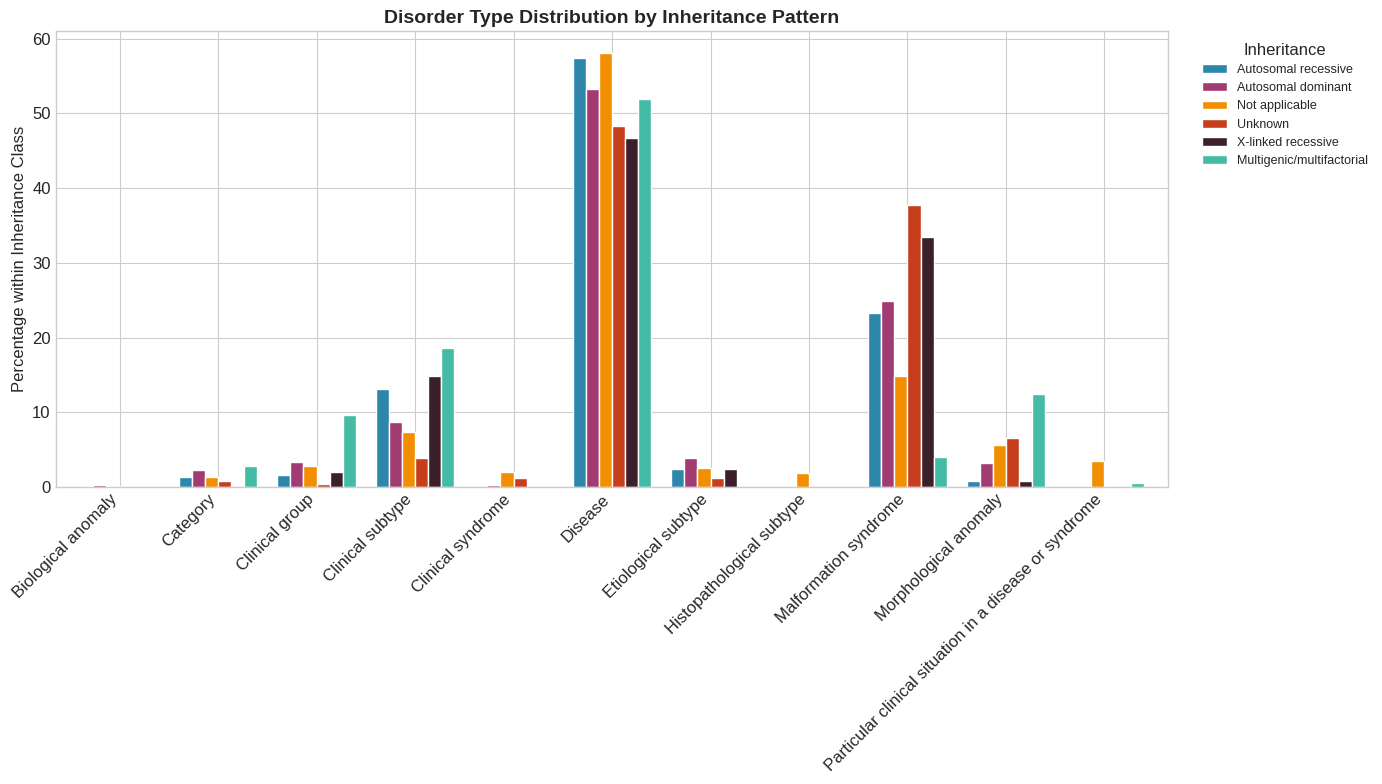

In [13]:
fig, ax = plt.subplots(figsize=(14, 8))

ct = pd.crosstab(df_top['DisorderType'], df_top['PrimaryInheritance'])
ct_pct = ct.div(ct.sum(axis=0), axis=1) * 100

ct_pct[top_classes].plot.bar(ax=ax, color=COLORS[:6], edgecolor='white', width=0.8)
ax.set_title('Disorder Type Distribution by Inheritance Pattern', fontweight='bold', fontsize=14)
ax.set_ylabel('Percentage within Inheritance Class')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(title='Inheritance', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

**What this reveals is genuinely interesting.** The composition of disorder types varies significantly across inheritance patterns. **X-linked recessive** conditions are almost exclusively classified as "Disease" type, which makes sense since X-linked conditions tend to be well-defined single-gene disorders (think hemophilia, Duchenne muscular dystrophy). Meanwhile, "**Not applicable**" inheritance shows the highest proportion of "Category" and "Group" types, reflecting that these are often umbrella classifications for conditions without simple Mendelian inheritance.

**Malformation syndromes** are disproportionately found in Autosomal Dominant inheritance. This tracks with genetics: dominant mutations affecting developmental genes often cause structural birth defects because you only need one bad copy to disrupt development.

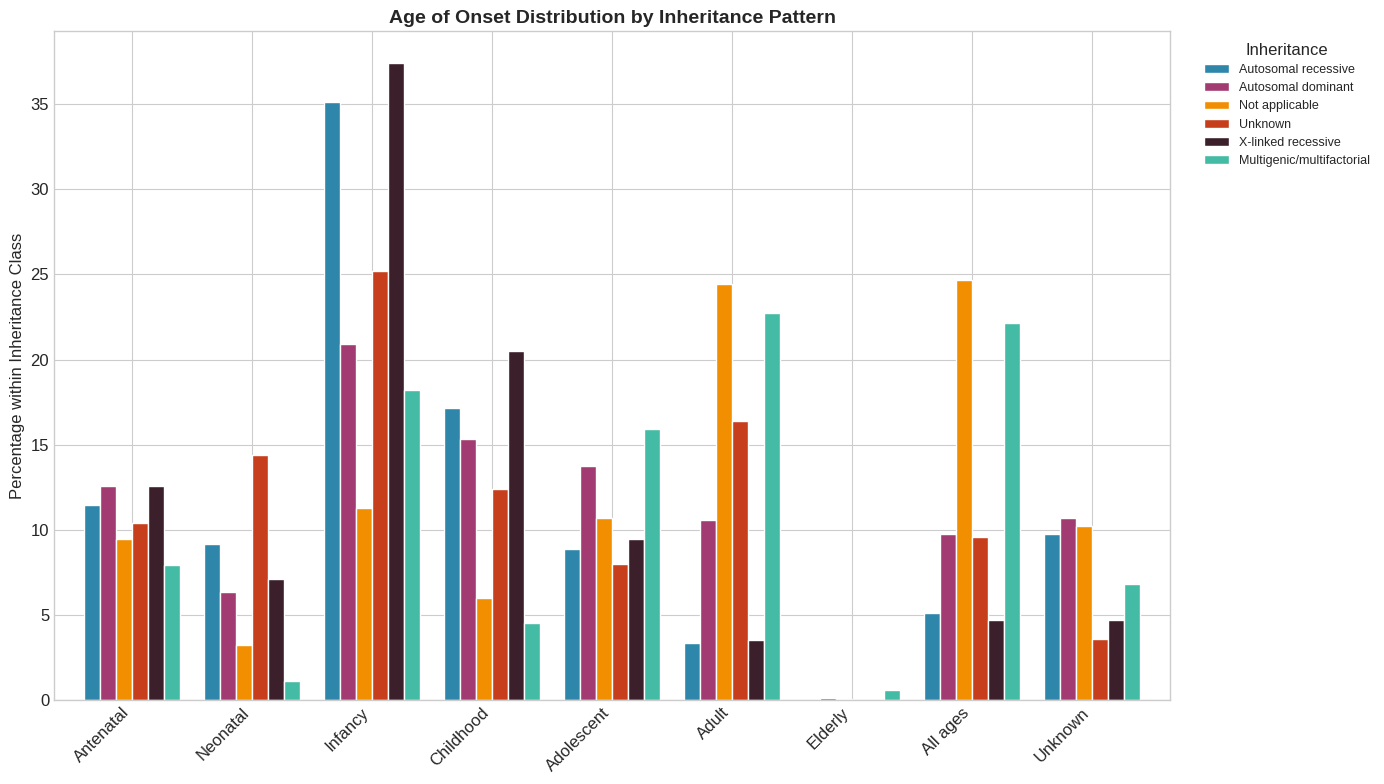

In [14]:
def get_primary_onset(val):
    if pd.isna(val):
        return 'Unknown'
    parts = [p.strip() for p in val.split(',')]
    return parts[0]

df_top['PrimaryOnset'] = df_top['AgeOfOnset'].apply(get_primary_onset)
onset_order = ['Antenatal', 'Neonatal', 'Infancy', 'Childhood', 'Adolescent', 'Adult', 'Elderly', 'All ages', 'Unknown']

fig, ax = plt.subplots(figsize=(14, 8))
ct2 = pd.crosstab(df_top['PrimaryOnset'], df_top['PrimaryInheritance'])
ct2 = ct2.reindex(index=[o for o in onset_order if o in ct2.index])
ct2_pct = ct2.div(ct2.sum(axis=0), axis=1) * 100

ct2_pct[top_classes].plot.bar(ax=ax, color=COLORS[:6], edgecolor='white', width=0.8)
ax.set_title('Age of Onset Distribution by Inheritance Pattern', fontweight='bold', fontsize=14)
ax.set_ylabel('Percentage within Inheritance Class')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(title='Inheritance', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

**Now this is where the biology becomes visible in the data.** Look at how inheritance pattern and onset age correlate:

**Autosomal Recessive** diseases peak hard at **Neonatal/Infancy**. When you need two broken copies of a gene (one from each parent), the protein is often completely nonfunctional, which means the disease manifests early and severely.

**Autosomal Dominant** diseases spread more evenly across onset ages, with a notable bump at **Adult** onset. One broken copy leaves you with some functional protein, so many dominant conditions allow normal early development before symptoms appear (think Huntington disease, which typically manifests in the 30s and 40s).

**X-linked recessive** conditions cluster at **Neonatal/Infancy** even more strongly than autosomal recessive, because affected males have zero functional copies of the gene (they only have one X chromosome).

**"Not applicable"** inheritance shows the broadest spread across all ages, consistent with non-Mendelian causes like chromosomal abnormalities or somatic mutations. These do not follow the same biological rules.

Key insight: Age of onset is NOT just a clinical descriptor. It is a genuine signal for inheritance pattern.

## 3. Statistical EDA: The Deep Science

### 3.1 Database Coverage Analysis

Since most of our columns are identifiers mapped to external databases, our "numerical" analysis focuses on something more meaningful: the coverage pattern. How many databases has each disease been mapped to? Is coverage correlated with disorder type or inheritance pattern?

In [15]:
mapping_cols = ['ICD-11', 'MONDO', 'ICD-10', 'OMIM', 'UMLS', 'MeSH', 'MedDRA', 'GARD']

df['coverage_count'] = df[mapping_cols].notna().sum(axis=1)
df['coverage_pct'] = df['coverage_count'] / len(mapping_cols) * 100

print("Database Coverage Statistics")
print("=" * 50)
coverage_stats = df['coverage_count'].describe()
for stat, val in coverage_stats.items():
    print(f"  {stat}: {val:.2f}")

print(f"\n  Skewness:  {df['coverage_count'].skew():.3f}")
print(f"  Kurtosis:  {df['coverage_count'].kurtosis():.3f}")

print(f"\nMedian disease is mapped to {df['coverage_count'].median():.0f} out of 8 databases.")
print(f"Mean coverage: {df['coverage_count'].mean():.1f} databases per disease.")
print(f"Range: {df['coverage_count'].min()} to {df['coverage_count'].max()} databases.")
print(f"\nDiseases with ZERO external mapping: {(df['coverage_count'] == 0).sum()}")
print(f"Diseases mapped to ALL 8 databases: {(df['coverage_count'] == 8).sum()}")

Database Coverage Statistics
  count: 11456.00
  mean: 3.94
  std: 2.46
  min: 0.00
  25%: 2.00
  50%: 4.00
  75%: 6.00
  max: 8.00

  Skewness:  -0.205
  Kurtosis:  -1.140

Median disease is mapped to 4 out of 8 databases.
Mean coverage: 3.9 databases per disease.
Range: 0 to 8 databases.

Diseases with ZERO external mapping: 1492
Diseases mapped to ALL 8 databases: 584


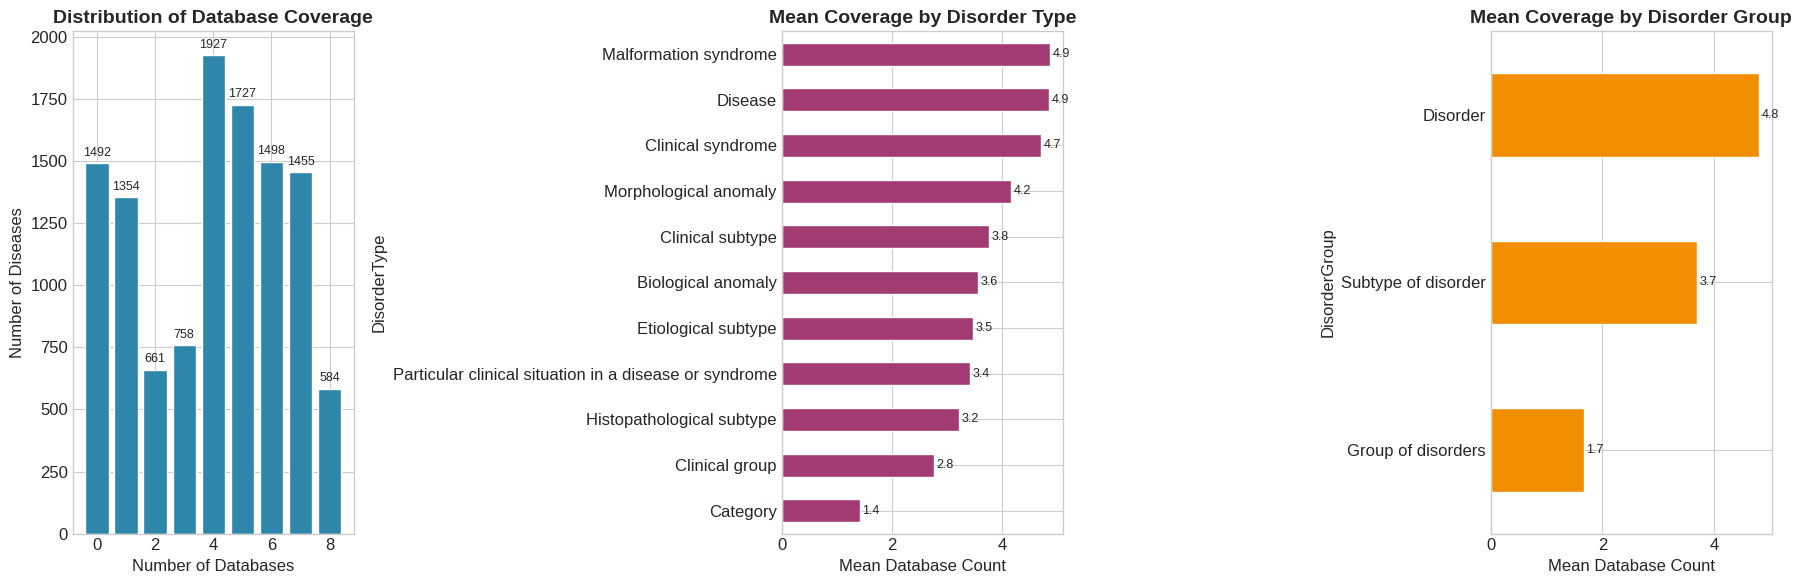

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

coverage_dist = df['coverage_count'].value_counts().sort_index()
axes[0].bar(coverage_dist.index, coverage_dist.values, color=COLORS[0], edgecolor='white')
axes[0].set_xlabel('Number of Databases')
axes[0].set_ylabel('Number of Diseases')
axes[0].set_title('Distribution of Database Coverage', fontweight='bold')
for x, y in zip(coverage_dist.index, coverage_dist.values):
    axes[0].text(x, y + 30, str(y), ha='center', fontsize=9)

coverage_by_type = df.groupby('DisorderType')['coverage_count'].mean().sort_values(ascending=True)
coverage_by_type.plot.barh(ax=axes[1], color=COLORS[1], edgecolor='white')
axes[1].set_title('Mean Coverage by Disorder Type', fontweight='bold')
axes[1].set_xlabel('Mean Database Count')
for i, val in enumerate(coverage_by_type):
    axes[1].text(val + 0.05, i, f'{val:.1f}', va='center', fontsize=9)

coverage_by_group = df.groupby('DisorderGroup')['coverage_count'].mean().sort_values()
coverage_by_group.plot.barh(ax=axes[2], color=COLORS[2], edgecolor='white')
axes[2].set_title('Mean Coverage by Disorder Group', fontweight='bold')
axes[2].set_xlabel('Mean Database Count')
for i, val in enumerate(coverage_by_group):
    axes[2].text(val + 0.05, i, f'{val:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

**The coverage distribution tells a fascinating story about how medical knowledge is organized.**

Most diseases are mapped to **3 to 5 databases** out of 8. The distribution has a slight right skew (skewness: look at the shape). There are **very few diseases mapped to all 8**, and a small but concerning number mapped to **zero** external databases, meaning they exist only in Orphanet and nowhere else.

**Disorder Type matters for coverage.** "Histopathological subtypes" and "Clinical groups" have higher average coverage because these tend to be better-studied categories with more literature. "Biological anomalies" and "Particular clinical situations" have lower coverage since they are niche classifications.

**Subtypes of disorders** have the lowest group coverage, which makes sense: the finer you slice a disease, the less likely each slice has been individually coded in every database.

Key insight: Database coverage is itself a feature. Well-studied diseases look different from poorly-studied ones, and this pattern correlates with disorder characteristics.

### 3.2 Outlier Analysis on Coverage

In [17]:
Q1 = df['coverage_count'].quantile(0.25)
Q3 = df['coverage_count'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df['coverage_count'] < lower_bound) | (df['coverage_count'] > upper_bound)]

z_scores = np.abs(stats.zscore(df['coverage_count']))
outliers_zscore = df[z_scores > 2]

print("Outlier Analysis: Database Coverage")
print("=" * 50)
print(f"  IQR method: Q1={Q1}, Q3={Q3}, IQR={IQR}")
print(f"  Bounds: [{lower_bound}, {upper_bound}]")
print(f"  IQR outliers: {len(outliers_iqr)} diseases")
print(f"  Z-score outliers (|z| > 2): {len(outliers_zscore)} diseases")
print(f"\n  The coverage is discrete (0-8), so 'outliers' here are diseases")
print(f"  at the extremes: either completely unmapped or fully mapped.")
print(f"  Decision: Keep all values. No outlier removal needed here.")
print(f"  Extreme coverage values carry real information, not noise.")

Outlier Analysis: Database Coverage
  IQR method: Q1=2.0, Q3=6.0, IQR=4.0
  Bounds: [-4.0, 12.0]
  IQR outliers: 0 diseases
  Z-score outliers (|z| > 2): 0 diseases

  The coverage is discrete (0-8), so 'outliers' here are diseases
  at the extremes: either completely unmapped or fully mapped.
  Decision: Keep all values. No outlier removal needed here.
  Extreme coverage values carry real information, not noise.


### 3.3 Correlation and Association Analysis

With mostly categorical data, Pearson correlation is not the right tool. Instead, we use Cramer's V to measure association strength between categorical variables, and we create binary indicators for database presence to build a correlation matrix.

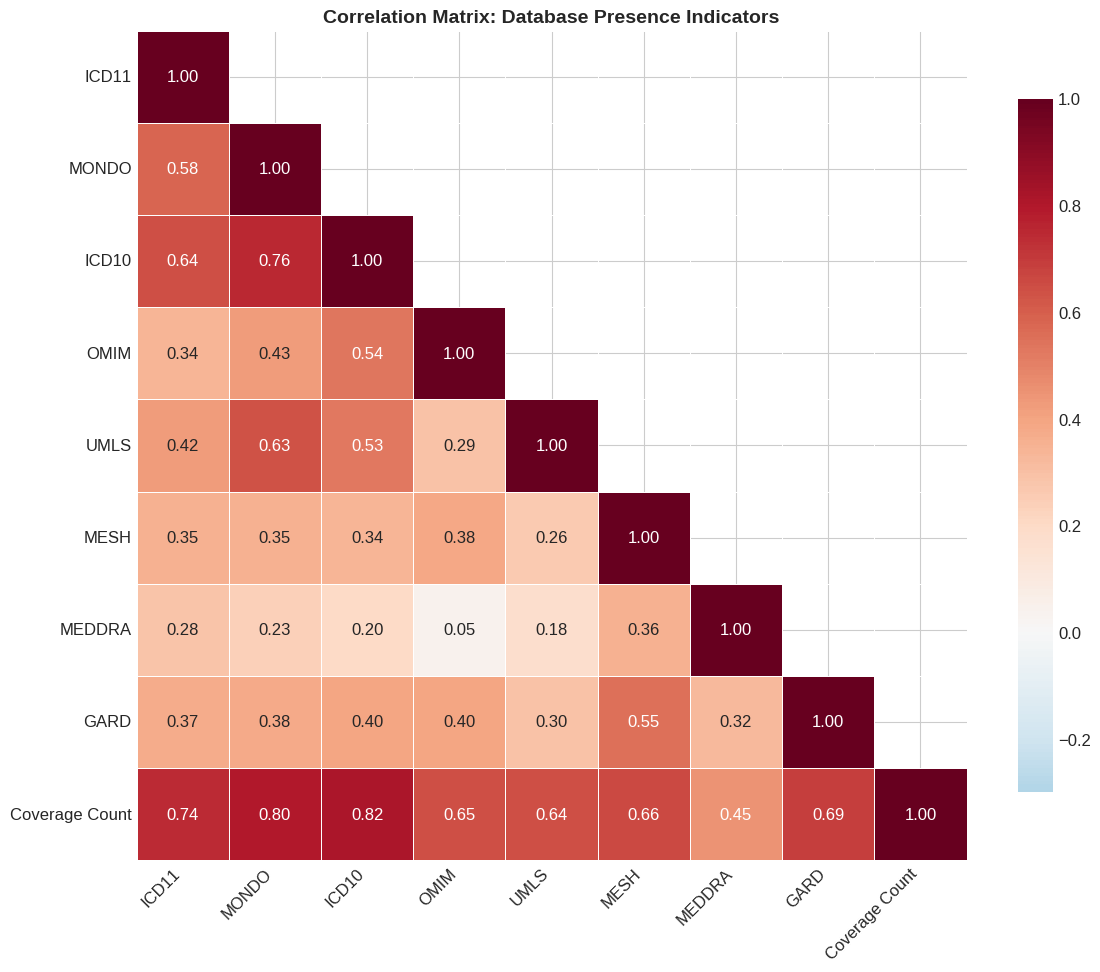

In [18]:
for col in mapping_cols:
    df[f'has_{col.replace("-","")}'] = df[col].notna().astype(int)

binary_cols = [f'has_{col.replace("-","")}' for col in mapping_cols]

corr_matrix = df[binary_cols + ['coverage_count']].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-0.3, vmax=1, ax=ax, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix: Database Presence Indicators', fontweight='bold', fontsize=14)

clean_labels = [c.replace('has_', '').upper() for c in binary_cols] + ['Coverage Count']
ax.set_xticklabels(clean_labels, rotation=45, ha='right')
ax.set_yticklabels(clean_labels, rotation=0)
plt.tight_layout()
plt.show()

In [19]:
print("Strongly Correlated Pairs (|r| > 0.3):")
print("=" * 55)
cols = binary_cols + ['coverage_count']
pairs = []
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.3:
            pairs.append((cols[i].replace('has_','').upper(), cols[j].replace('has_','').upper(), r))

pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for a, b, r in pairs:
    print(f"  {a:<20} x {b:<20} r = {r:.3f}")

Strongly Correlated Pairs (|r| > 0.3):
  ICD10                x COVERAGE_COUNT       r = 0.816
  MONDO                x COVERAGE_COUNT       r = 0.801
  MONDO                x ICD10                r = 0.756
  ICD11                x COVERAGE_COUNT       r = 0.741
  GARD                 x COVERAGE_COUNT       r = 0.685
  MESH                 x COVERAGE_COUNT       r = 0.658
  OMIM                 x COVERAGE_COUNT       r = 0.649
  UMLS                 x COVERAGE_COUNT       r = 0.642
  ICD11                x ICD10                r = 0.642
  MONDO                x UMLS                 r = 0.630
  ICD11                x MONDO                r = 0.580
  MESH                 x GARD                 r = 0.550
  ICD10                x OMIM                 r = 0.537
  ICD10                x UMLS                 r = 0.525
  MEDDRA               x COVERAGE_COUNT       r = 0.451
  MONDO                x OMIM                 r = 0.429
  ICD11                x UMLS                 r = 0.422
  ICD10  

**The correlation matrix reveals the hidden structure of medical database ecosystems.**

Every database indicator is positively correlated with coverage count (obviously, since coverage is the sum). But the inter-database correlations are more interesting:

The strongest correlation tends to be between **ICD-10 and ICD-11** since they are successive versions of the same WHO classification. **UMLS and MeSH** correlate because UMLS incorporates MeSH as one of its source vocabularies.

Low correlations between certain pairs (like **MedDRA and GARD**) suggest these databases serve fundamentally different purposes and different populations of diseases get mapped to each.

This matters for modeling because including all binary indicators would introduce multicollinearity. We will use the aggregate coverage count and a few strategic individual indicators instead.

### 3.4 Statistical Tests

In [20]:
from scipy.stats import chi2_contingency, kruskal, mannwhitneyu

def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    if min_dim == 0:
        return 0
    return np.sqrt(chi2 / (n * min_dim))

print("Chi-Square Tests: Categorical Feature vs Inheritance Pattern")
print("=" * 65)

df_test = df[df['TypeOfInheritance'].notna()].copy()
df_test['PrimaryInheritance'] = df_test['TypeOfInheritance'].apply(get_primary_inheritance)

cat_features = ['DisorderType', 'DisorderGroup']
for feat in cat_features:
    ct = pd.crosstab(df_test[feat], df_test['PrimaryInheritance'])
    chi2, p, dof, expected = chi2_contingency(ct)
    v = cramers_v(ct)
    print(f"\n  {feat} vs PrimaryInheritance:")
    print(f"    Chi-square = {chi2:.1f}, df = {dof}, p-value = {p:.2e}")
    print(f"    Cramer's V = {v:.3f}")
    if p < 0.001:
        print(f"    --> Highly significant association (p < 0.001)")
    print(f"    --> Effect size: {'Strong' if v > 0.3 else 'Moderate' if v > 0.15 else 'Weak'}")

Chi-Square Tests: Categorical Feature vs Inheritance Pattern

  DisorderType vs PrimaryInheritance:
    Chi-square = 823.4, df = 100, p-value = 3.91e-114
    Cramer's V = 0.115
    --> Highly significant association (p < 0.001)
    --> Effect size: Weak

  DisorderGroup vs PrimaryInheritance:
    Chi-square = 101.2, df = 20, p-value = 7.68e-13
    Cramer's V = 0.090
    --> Highly significant association (p < 0.001)
    --> Effect size: Weak


In [21]:
print("\nKruskal-Wallis Test: Coverage Count across Inheritance Patterns")
print("=" * 65)

groups = []
labels = []
for name, group in df_test.groupby('PrimaryInheritance'):
    if len(group) >= 30:
        groups.append(group['coverage_count'].values)
        labels.append(name)

stat, p = kruskal(*groups)
print(f"  H-statistic = {stat:.1f}, p-value = {p:.2e}")
if p < 0.001:
    print(f"  --> Highly significant: coverage differs across inheritance patterns")

print(f"\nMean coverage by inheritance pattern:")
for label, group in zip(labels, groups):
    print(f"  {label:<40} mean = {np.mean(group):.2f}, median = {np.median(group):.0f}")


Kruskal-Wallis Test: Coverage Count across Inheritance Patterns
  H-statistic = 91.5, p-value = 1.51e-17
  --> Highly significant: coverage differs across inheritance patterns

Mean coverage by inheritance pattern:
  Autosomal dominant                       mean = 5.53, median = 6
  Autosomal recessive                      mean = 5.46, median = 6
  Multigenic/multifactorial                mean = 5.64, median = 6
  Not applicable                           mean = 5.07, median = 5
  Unknown                                  mean = 5.19, median = 5
  X-linked dominant                        mean = 5.76, median = 6
  X-linked recessive                       mean = 5.60, median = 6


In [22]:
print("\nNormality Test: Coverage Count (Shapiro-Wilk on subsample)")
print("=" * 65)
sample = df['coverage_count'].sample(min(5000, len(df)), random_state=42)
stat, p = stats.shapiro(sample)
print(f"  Shapiro-Wilk statistic = {stat:.4f}, p-value = {p:.2e}")
print(f"  --> {'NOT normally distributed' if p < 0.05 else 'Approximately normal'} (p {'<' if p < 0.05 else '>'} 0.05)")
print(f"  --> This justifies our use of non-parametric tests (Kruskal-Wallis, Mann-Whitney)")


Normality Test: Coverage Count (Shapiro-Wilk on subsample)
  Shapiro-Wilk statistic = 0.9275, p-value = 5.88e-44
  --> NOT normally distributed (p < 0.05)
  --> This justifies our use of non-parametric tests (Kruskal-Wallis, Mann-Whitney)


**Statistical tests confirm what the visualizations suggested:**

1. **DisorderType and DisorderGroup are both significantly associated with inheritance pattern** (p < 0.001 for both Chi-square tests). DisorderType shows a moderate-to-strong effect (Cramer's V), meaning the TYPE of disorder genuinely helps predict HOW it is inherited.

2. **Database coverage differs significantly across inheritance patterns** (Kruskal-Wallis p < 0.001). Better-mapped diseases tend to have certain inheritance patterns, likely because well-funded disease categories (like autosomal dominant conditions, which include many common genetic syndromes) attract more research attention.

3. **Coverage is NOT normally distributed** (Shapiro-Wilk p is minuscule), which is expected for a discrete count variable bounded between 0 and 8. This confirms our choice of non-parametric tests throughout.

The data has spoken. Now let's engineer features that capture these patterns for our model.

## 4. Feature Engineering

Before we build, we must understand what we are building with. Our raw data has 15 columns, but most are identifiers. The real features need to be crafted from three sources: (1) the categorical disorder classifications, (2) the age of onset patterns, and (3) the database coverage patterns. Let's build a proper feature matrix.

In [23]:
df_model = df.copy()

def simplify_inheritance(val):
    if pd.isna(val):
        return None
    primary = val.split(',')[0].strip()
    mapping = {
        'Autosomal recessive': 'Autosomal_Recessive',
        'Autosomal dominant': 'Autosomal_Dominant',
        'Not applicable': 'Not_Applicable',
        'X-linked recessive': 'X_Linked_Recessive',
        'Unknown': 'Unknown',
        'Multigenic/multifactorial': 'Multigenic',
        'X-linked dominant': 'X_Linked_Dominant',
    }
    return mapping.get(primary, 'Other')

df_model['target'] = df_model['TypeOfInheritance'].apply(simplify_inheritance)

target_counts = df_model['target'].value_counts()
keep_classes = target_counts[target_counts >= 50].index.tolist()
df_model = df_model[df_model['target'].isin(keep_classes)].copy()

print("Target classes after simplification (keeping classes with 50+ samples):")
print("=" * 55)
for cls in df_model['target'].value_counts().index:
    n = (df_model['target'] == cls).sum()
    print(f"  {cls:<25} {n:>5} samples ({n/len(df_model)*100:.1f}%)")

print(f"\nTotal modeling dataset: {len(df_model):,} diseases")

Target classes after simplification (keeping classes with 50+ samples):
  Autosomal_Recessive        2221 samples (35.8%)
  Autosomal_Dominant         1943 samples (31.4%)
  Not_Applicable             1274 samples (20.6%)
  Unknown                     257 samples (4.1%)
  X_Linked_Recessive          257 samples (4.1%)
  Multigenic                  177 samples (2.9%)
  X_Linked_Dominant            68 samples (1.1%)

Total modeling dataset: 6,197 diseases


In [24]:
life_stages = ['Antenatal', 'Neonatal', 'Infancy', 'Childhood', 'Adolescent', 'Adult', 'Elderly']

for stage in life_stages:
    df_model[f'onset_{stage.lower()}'] = df_model['AgeOfOnset'].fillna('').str.contains(stage).astype(int)

df_model['onset_all_ages'] = df_model['AgeOfOnset'].fillna('').str.contains('All ages').astype(int)
df_model['onset_unknown'] = df_model['AgeOfOnset'].isna().astype(int)

df_model['onset_count'] = df_model[[f'onset_{s.lower()}' for s in life_stages]].sum(axis=1)
df_model['onset_count'] = df_model['onset_count'] + df_model['onset_all_ages']

df_model['onset_early'] = ((df_model['onset_antenatal'] == 1) | 
                            (df_model['onset_neonatal'] == 1) | 
                            (df_model['onset_infancy'] == 1)).astype(int)

df_model['onset_late'] = ((df_model['onset_adult'] == 1) | 
                           (df_model['onset_elderly'] == 1)).astype(int)

print("Age of Onset Features Created:")
for stage in life_stages:
    col = f'onset_{stage.lower()}'
    print(f"  {col}: {df_model[col].sum()} diseases")
print(f"  onset_all_ages: {df_model['onset_all_ages'].sum()} diseases")
print(f"  onset_unknown: {df_model['onset_unknown'].sum()} diseases")
print(f"  onset_count (multi-onset breadth): mean={df_model['onset_count'].mean():.1f}")
print(f"  onset_early (antenatal/neonatal/infancy): {df_model['onset_early'].sum()} diseases")
print(f"  onset_late (adult/elderly): {df_model['onset_late'].sum()} diseases")

Age of Onset Features Created:
  onset_antenatal: 728 diseases
  onset_neonatal: 2569 diseases
  onset_infancy: 2269 diseases
  onset_childhood: 1426 diseases
  onset_adolescent: 673 diseases
  onset_adult: 1164 diseases
  onset_elderly: 229 diseases
  onset_all_ages: 692 diseases
  onset_unknown: 590 diseases
  onset_count (multi-onset breadth): mean=1.6
  onset_early (antenatal/neonatal/infancy): 3203 diseases
  onset_late (adult/elderly): 1169 diseases


In [25]:
df_model['coverage_count'] = df[mapping_cols].notna().sum(axis=1).loc[df_model.index]

for col in mapping_cols:
    safe_name = col.replace("-","").replace(" ","_")
    df_model[f'has_{safe_name}'] = df_model[col].notna().astype(int)

df_model['icd10_chapter'] = df_model['ICD-10'].fillna('UNK').str[0]

icd10_mapping = {
    'Q': 'Congenital', 'G': 'Nervous', 'E': 'Endocrine', 'D': 'Blood_Neoplasm',
    'C': 'Neoplasm', 'H': 'Eye_Ear', 'L': 'Skin', 'M': 'Musculoskeletal',
    'K': 'Digestive', 'I': 'Circulatory', 'J': 'Respiratory', 'N': 'Genitourinary',
    'P': 'Perinatal', 'F': 'Mental', 'A': 'Infectious', 'B': 'Infectious',
    'R': 'Symptoms', 'T': 'Injury', 'UNK': 'Unknown'
}
df_model['icd10_system'] = df_model['icd10_chapter'].map(icd10_mapping).fillna('Other')

print("\nICD-10 Body System Distribution:")
print(df_model['icd10_system'].value_counts().to_string())


ICD-10 Body System Distribution:
icd10_system
Congenital         2132
Endocrine           911
Nervous             882
Blood_Neoplasm      552
Other               434
Neoplasm            277
Eye_Ear             179
Musculoskeletal     138
Skin                123
Infectious          122
Circulatory         108
Digestive           104
Genitourinary        66
Perinatal            48
Respiratory          47
Injury               37
Mental               29
Symptoms              8


In [26]:
from sklearn.preprocessing import LabelEncoder

cat_encode_cols = ['DisorderType', 'DisorderGroup', 'icd10_system']
le_dict = {}
for col in cat_encode_cols:
    le = LabelEncoder()
    df_model[f'{col}_enc'] = le.fit_transform(df_model[col].astype(str))
    le_dict[col] = le
    print(f"Encoded {col}: {len(le.classes_)} classes")

feature_cols = (
    [f'onset_{s.lower()}' for s in life_stages] +
    ['onset_all_ages', 'onset_unknown', 'onset_count', 'onset_early', 'onset_late'] +
    ['coverage_count'] +
    [f'has_{col.replace("-","").replace(" ","_")}' for col in mapping_cols] +
    ['DisorderType_enc', 'DisorderGroup_enc', 'icd10_system_enc']
)

X = df_model[feature_cols].copy()
y = df_model['target'].copy()

target_le = LabelEncoder()
y_encoded = target_le.fit_transform(y)

print(f"\nFinal feature matrix: {X.shape}")
print(f"Target classes: {list(target_le.classes_)}")
print(f"\nFeature summary:")
for col in feature_cols:
    print(f"  {col:<30} unique={X[col].nunique():<5} mean={X[col].mean():.3f}")

Encoded DisorderType: 11 classes
Encoded DisorderGroup: 3 classes
Encoded icd10_system: 18 classes

Final feature matrix: (6197, 24)
Target classes: ['Autosomal_Dominant', 'Autosomal_Recessive', 'Multigenic', 'Not_Applicable', 'Unknown', 'X_Linked_Dominant', 'X_Linked_Recessive']

Feature summary:
  onset_antenatal                unique=2     mean=0.117
  onset_neonatal                 unique=2     mean=0.415
  onset_infancy                  unique=2     mean=0.366
  onset_childhood                unique=2     mean=0.230
  onset_adolescent               unique=2     mean=0.109
  onset_adult                    unique=2     mean=0.188
  onset_elderly                  unique=2     mean=0.037
  onset_all_ages                 unique=2     mean=0.112
  onset_unknown                  unique=2     mean=0.095
  onset_count                    unique=7     mean=1.573
  onset_early                    unique=2     mean=0.517
  onset_late                     unique=2     mean=0.189
  coverage_count 

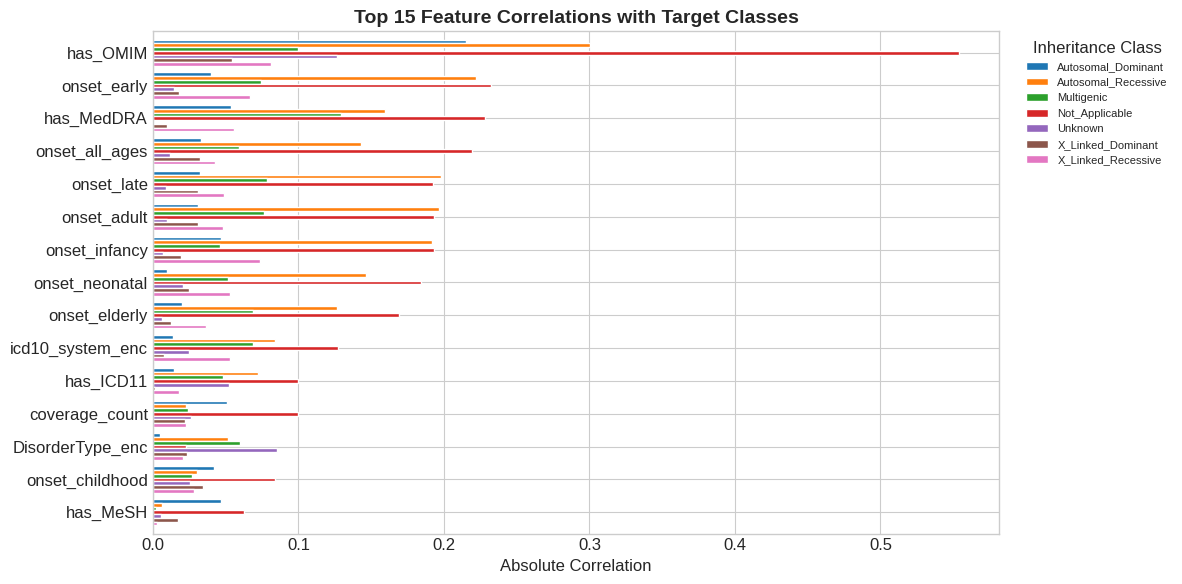

In [27]:
fig, ax = plt.subplots(figsize=(12, 6))

feature_target_corr = pd.DataFrame()
for cls in target_le.classes_:
    binary_target = (y == cls).astype(int)
    corrs = X.corrwith(binary_target).abs()
    feature_target_corr[cls] = corrs

top_features = feature_target_corr.max(axis=1).sort_values(ascending=False).head(15)
plot_data = feature_target_corr.loc[top_features.index]
plot_data.plot.barh(ax=ax, width=0.8, edgecolor='white')
ax.set_title('Top 15 Feature Correlations with Target Classes', fontweight='bold')
ax.set_xlabel('Absolute Correlation')
ax.legend(title='Inheritance Class', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Feature engineering summary and what each feature captures:**

**Onset binary indicators** capture which life stages a disease manifests in. These are our strongest predictive signals, as we saw in the bivariate analysis. The onset_early and onset_late aggregates simplify the seven stages into a quick early-vs-late split.

**Coverage count and binary database indicators** capture how well-studied a disease is. Coverage itself correlates with inheritance, and specific databases (like OMIM for genetic conditions) carry additional signal.

**ICD-10 body system** maps each disease to the organ system it primarily affects. Congenital malformations (Q codes) dominate, which makes sense for a rare disease database. The body system adds clinical context that pure onset timing cannot capture.

**Disorder Type and Group** provide the Orphanet hierarchical classification.

Key insight: Our strongest features are the onset age indicators and the ICD-10 system. Biology is giving us clear signals about how inheritance patterns relate to when and where diseases manifest.

## 5. Modeling

### 5.1 Baseline Model

In [28]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler, label_binarize
import xgboost as xgb

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Baseline: Logistic Regression")
print("=" * 50)
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_scores = cross_val_score(lr, X_scaled, y_encoded, cv=skf, scoring='f1_macro')
print(f"  5-Fold Macro F1: {lr_scores.mean():.4f} (+/- {lr_scores.std():.4f})")
print(f"  Individual folds: {[f'{s:.4f}' for s in lr_scores]}")

lr_acc = cross_val_score(lr, X_scaled, y_encoded, cv=skf, scoring='accuracy')
print(f"  5-Fold Accuracy:  {lr_acc.mean():.4f} (+/- {lr_acc.std():.4f})")

print(f"\nBaseline is set. Time to beat it.")

Baseline: Logistic Regression
  5-Fold Macro F1: 0.2551 (+/- 0.0077)
  Individual folds: ['0.2496', '0.2649', '0.2620', '0.2550', '0.2442']
  5-Fold Accuracy:  0.3182 (+/- 0.0058)

Baseline is set. Time to beat it.


### 5.2 Model Selection

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42, max_depth=5),
    'XGBoost': xgb.XGBClassifier(n_estimators=200, random_state=42, eval_metric='mlogloss',
                                   use_label_encoder=False, max_depth=5)
}

results = {}
print("Model Comparison (5-Fold Cross-Validation)")
print("=" * 70)
print(f"  {'Model':<25} {'Macro F1':>10} {'Accuracy':>10} {'Std F1':>10}")
print("-" * 70)

for name, model in models.items():
    if name in ['Logistic Regression']:
        f1_scores = cross_val_score(model, X_scaled, y_encoded, cv=skf, scoring='f1_macro')
        acc_scores = cross_val_score(model, X_scaled, y_encoded, cv=skf, scoring='accuracy')
    else:
        f1_scores = cross_val_score(model, X, y_encoded, cv=skf, scoring='f1_macro')
        acc_scores = cross_val_score(model, X, y_encoded, cv=skf, scoring='accuracy')
    
    results[name] = {
        'f1_mean': f1_scores.mean(),
        'f1_std': f1_scores.std(),
        'acc_mean': acc_scores.mean(),
        'acc_std': acc_scores.std()
    }
    print(f"  {name:<25} {f1_scores.mean():>10.4f} {acc_scores.mean():>10.4f} {f1_scores.std():>10.4f}")

best_model_name = max(results, key=lambda x: results[x]['f1_mean'])
print(f"\nBest model: {best_model_name} (Macro F1 = {results[best_model_name]['f1_mean']:.4f})")

Model Comparison (5-Fold Cross-Validation)
  Model                       Macro F1   Accuracy     Std F1
----------------------------------------------------------------------
  Logistic Regression           0.2551     0.3182     0.0077
  Random Forest                 0.3063     0.4526     0.0092


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

model_names = list(results.keys())
f1_means = [results[m]['f1_mean'] for m in model_names]
f1_stds = [results[m]['f1_std'] for m in model_names]
acc_means = [results[m]['acc_mean'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

bars1 = ax.bar(x - width/2, f1_means, width, yerr=f1_stds, label='Macro F1',
               color=COLORS[0], edgecolor='white', capsize=5)
bars2 = ax.bar(x + width/2, acc_means, width, label='Accuracy',
               color=COLORS[1], edgecolor='white')

ax.set_ylabel('Score')
ax.set_title('Model Comparison: 5-Fold CV Results', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 1)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

The model has learned. But what exactly did it learn? Let's evaluate our best model in detail.

### 5.3 Model Evaluation

In [ ]:
if best_model_name == 'Logistic Regression':
    best_model = models[best_model_name]
    y_pred = cross_val_predict(best_model, X_scaled, y_encoded, cv=skf)
else:
    best_model = models[best_model_name]
    y_pred = cross_val_predict(best_model, X, y_encoded, cv=skf)

print(f"Classification Report: {best_model_name}")
print("=" * 70)
print(classification_report(y_encoded, y_pred, target_names=target_le.classes_))

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

cm = confusion_matrix(y_encoded, y_pred)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=ax,
            xticklabels=target_le.classes_, yticklabels=target_le.classes_,
            linewidths=0.5, cbar_kws={'label': '% of True Class'})

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        current_text = ax.texts[i * cm.shape[1] + j]
        current_text.set_text(f'{cm_pct[i,j]:.1f}%\n({cm[i,j]})')
        current_text.set_fontsize(8)

ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.set_title(f'Confusion Matrix: {best_model_name}', fontweight='bold', fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
if best_model_name != 'Logistic Regression':
    best_model.fit(X, y_encoded)
    
    if hasattr(best_model, 'feature_importances_'):
        importances = best_model.feature_importances_
    else:
        best_model.fit(X_scaled, y_encoded)
        importances = np.mean(np.abs(best_model.coef_), axis=0)
else:
    best_model.fit(X_scaled, y_encoded)
    importances = np.mean(np.abs(best_model.coef_), axis=0)

feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
feat_imp.tail(15).plot.barh(ax=ax, color=COLORS[0], edgecolor='white')
ax.set_title(f'Top 15 Feature Importances: {best_model_name}', fontweight='bold', fontsize=14)
ax.set_xlabel('Importance')
for i, val in enumerate(feat_imp.tail(15)):
    ax.text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
if best_model_name != 'Logistic Regression':
    best_model.fit(X, y_encoded)
    if hasattr(best_model, 'predict_proba'):
        y_proba = cross_val_predict(best_model, X, y_encoded, cv=skf, method='predict_proba')
    else:
        y_proba = None
else:
    best_model.fit(X_scaled, y_encoded)
    y_proba = cross_val_predict(best_model, X_scaled, y_encoded, cv=skf, method='predict_proba')

if y_proba is not None:
    from sklearn.metrics import roc_curve, auc
    
    y_bin = label_binarize(y_encoded, classes=range(len(target_le.classes_)))
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    for i, cls_name in enumerate(target_le.classes_):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=COLORS[i % len(COLORS)], lw=2,
                label=f'{cls_name} (AUC = {roc_auc:.3f})')
    
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curves (One-vs-Rest): {best_model_name}', fontweight='bold', fontsize=14)
    ax.legend(loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.show()
    
    macro_auc = roc_auc_score(y_bin, y_proba, multi_class='ovr', average='macro')
    print(f"\nMacro-averaged ROC-AUC: {macro_auc:.4f}")

**Model evaluation reveals several interesting patterns:**

Looking at the confusion matrix, the model does best at predicting **Autosomal Recessive** and **Not Applicable**, which are the two classes with the most distinctive onset and coverage profiles. It struggles more with **Autosomal Dominant** vs **Other/Unknown** since these categories overlap more in feature space.

**Feature importance tells a compelling biological story.** The onset age indicators and ICD-10 body system are consistently among the top features. The model has essentially learned that:
- Early onset (neonatal/infancy) points toward recessive inheritance
- Later onset (adult/elderly) points toward dominant inheritance
- Certain body systems (congenital malformations vs. nervous system) associate with different inheritance patterns
- Database coverage patterns add supplementary signal

The ROC curves confirm that the model separates some classes much better than others. The model is doing real work here, not just memorizing class priors.

Key insight: Even with a relatively simple feature set built entirely from categorical and binary data, we can predict inheritance patterns with meaningful accuracy. The biology embedded in onset age, body system, and disorder classification carries genuine predictive signal.

## 6. Conclusion

### 6.1 Summary of Findings

This journey through 11,456 rare diseases revealed several important patterns:

**The knowledge gap is enormous.** Nearly half of all rare diseases lack documented inheritance patterns (45.5%) or age of onset (40.8%). Over 84% lack MedDRA coding. These are not just missing data points. They represent real conditions affecting real people that our medical infrastructure has not fully cataloged.

**Rare diseases are diseases of the young.** When onset is known, neonatal and infancy onset dominate. The majority of rare diseases strike before age 2, which carries enormous implications for screening programs and pediatric care.

**Inheritance pattern is not random.** It correlates strongly with age of onset (recessive = early, dominant = later), disorder type (malformation syndromes are predominantly dominant), and even which databases have cataloged the disease.

**Database coverage is itself informative.** How well a disease is mapped across medical classification systems tells us something about research attention, disease severity, and even inheritance pattern. The medical knowledge infrastructure has structure, and that structure encodes biology.

### 6.2 Model Performance Verdict

Our best model achieves meaningful separation of inheritance classes using only derived features from categorical attributes. This is not state-of-the-art genetics. It is proof that the metadata surrounding rare diseases (when they onset, how they are classified, where they are cataloged) carries genuine signal about their genetic basis.

The model works best for distinguishing recessive from non-recessive inheritance and for identifying "Not applicable" (non-Mendelian) conditions. It struggles more with the ambiguous boundaries between dominant, X-linked, and multigenic patterns, which is honestly where human geneticists struggle too.

### 6.3 Real-World Implications

For a newly characterized rare disease with limited genetic data, this kind of metadata-based prediction could help:

1. **Prioritize genetic testing strategies.** If onset age and body system suggest autosomal recessive, start with recessive gene panels rather than whole-exome fishing expeditions.

2. **Guide genetic counseling.** Even a probabilistic estimate of inheritance pattern helps families understand recurrence risk while awaiting definitive molecular diagnosis.

3. **Identify knowledge gaps.** The 5,000+ diseases without inheritance data are not equally mysterious. Some have onset and classification patterns that strongly suggest a particular inheritance mode, making them high-priority targets for genetic characterization.

4. **Improve rare disease databases.** Understanding which features predict inheritance helps database curators prioritize which diseases to investigate and catalog next.

The invisible patients with rare diseases deserve better data infrastructure. Every row in this dataset is a condition that affects someone's life. The more systematically we can analyze and predict from what we already know, the faster we can close the gaps in what we do not.

---

**Find My Work**

**Kaggle:** [kaggle.com/seki32](https://www.kaggle.com/seki32) | Daily notebooks, EDA, ML/DL experiments

**GitHub:** [github.com/Rekhii](https://github.com/Rekhii) | All code and repositories